<a href="https://colab.research.google.com/github/goncalo-mateus/portfolio-optimization-engine/blob/main/Portfolio_Optimization_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ingestão de dados em curso para os ativos: GOOGL, JPM, NVDA...
             PORTFOLIO OPTIMIZATION REPORT
Max Sharpe Ratio Portfolio:
  • Expected Annual Return: 52.81%
  • Annualized Volatility: 25.11%
  • Sharpe Ratio:           1.94

Optimal Weights Allocation:
  • GOOGL   : 23.41%
  • JPM     : 41.64%
  • NVDA    : 34.95%
-----------------------------------------------------------------
Minimum Variance Portfolio:
  • Expected Annual Return: 35.98%
  • Annualized Volatility: 20.32%


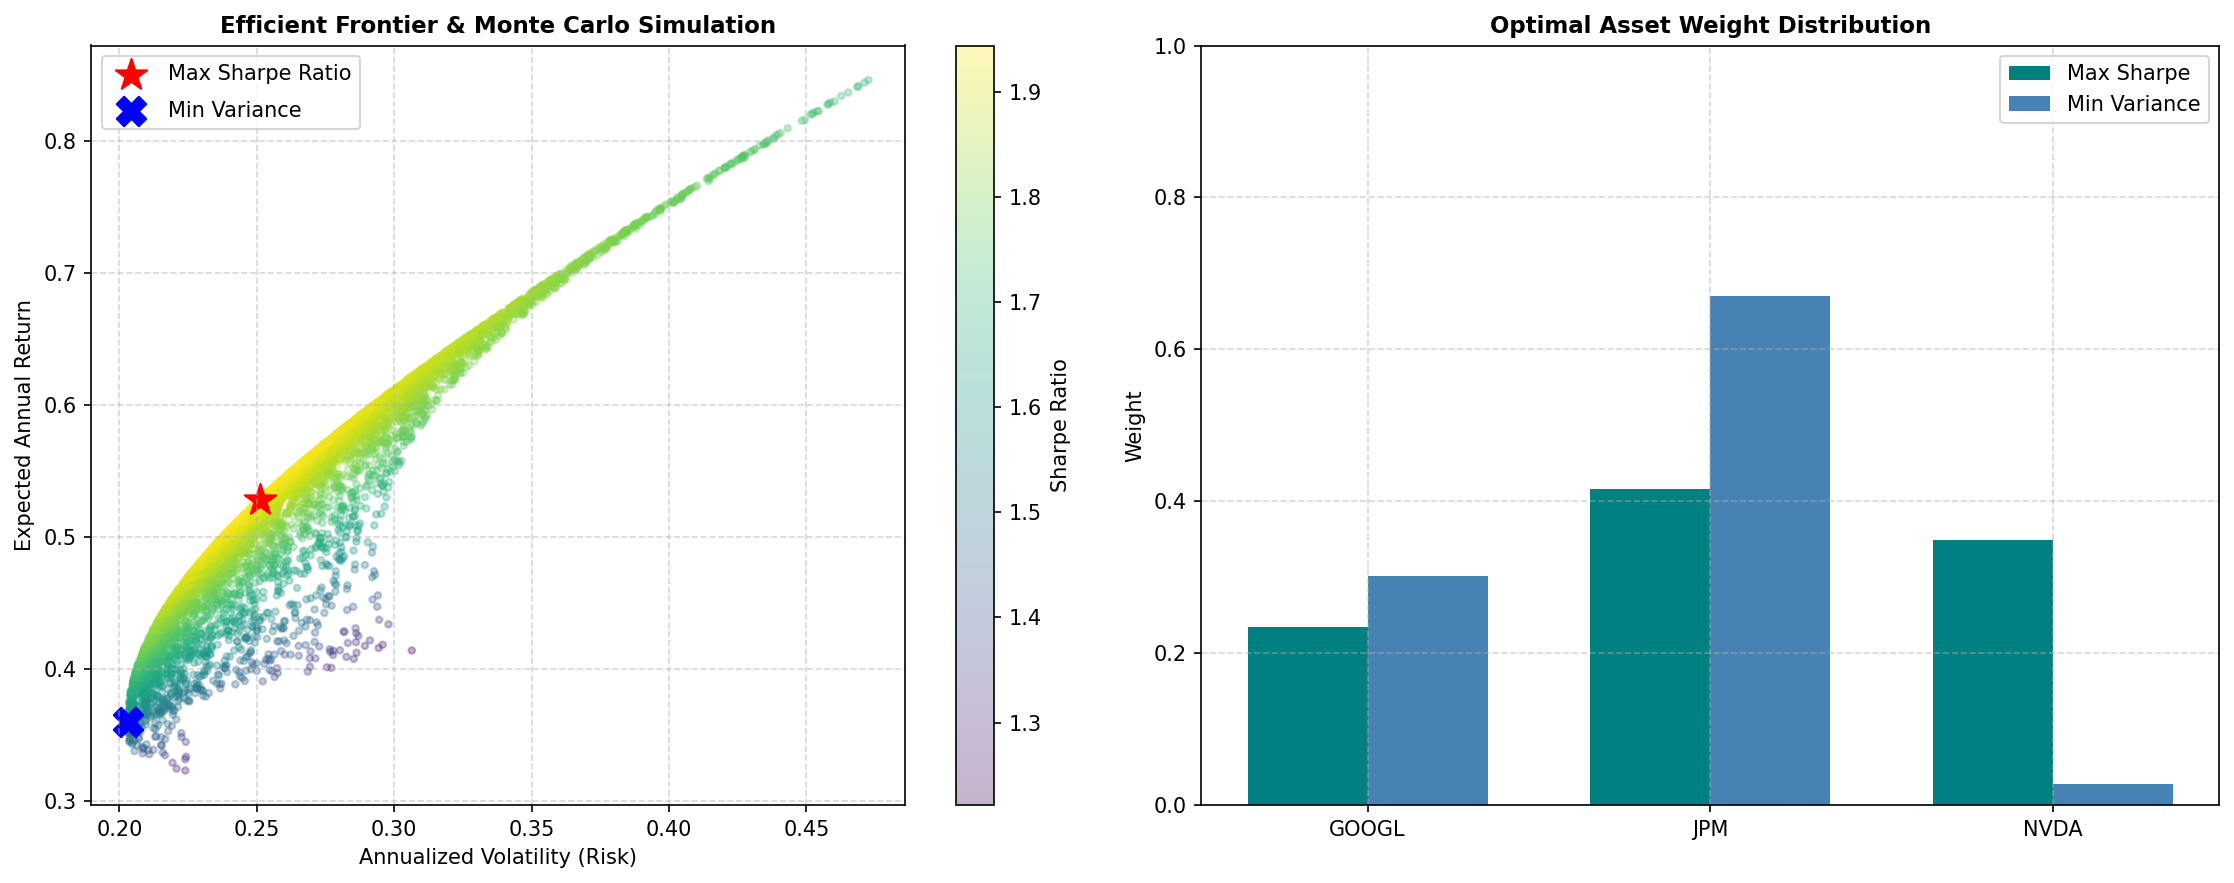

In [1]:
# @title Portfolio Optimization Engine (Form-Based HUD) { display-mode: "form" }

# @markdown ### 1. Asset Selection (Choose Portfolio Components)
Asset_1 = "GOOGL" # @param ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "JPM", "V", "JNJ", "PG", "XOM", "SPY", "QQQ"]
Asset_2 = "JPM" # @param ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "JPM", "V", "JNJ", "PG", "XOM", "SPY", "QQQ"]
Asset_3 = "NVDA" # @param ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "JPM", "V", "JNJ", "PG", "XOM", "SPY", "QQQ"]
Asset_4 = "NVDA" # @param ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "JPM", "V", "JNJ", "PG", "XOM", "SPY", "QQQ"]

# @markdown ---
# @markdown ### 2. Optimization Parameters
Risk_Free_Rate = 0.04 # @param {type:"number"}
Num_Portfolios = 7000 # @param {type:"slider", min:1000, max:20000, step:1000}

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

import io
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.optimize as sco
from IPython.display import display, Image

# Build unique ticker list from HUD dropdown selections
raw_assets = [Asset_1, Asset_2, Asset_3, Asset_4]
ticker_list = list(dict.fromkeys(raw_assets)) # Remove duplicates while preserving order

if len(ticker_list) < 2:
    raise ValueError("Por favor escolhe pelo menos 2 ativos diferentes nos seletores da HUD.")

print(f"Ingestão de dados em curso para os ativos: {', '.join(ticker_list)}...")
data = yf.download(ticker_list, start="2023-01-01", progress=False)["Close"]

# Calculate Daily and Annualized Metrics
returns = data.pct_change().dropna()
num_assets = len(ticker_list)

mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

# Optimization Helper Functions
def portfolio_performance(weights, mean_returns, cov_matrix):
    p_ret = np.sum(mean_returns * weights)
    p_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return p_ret, p_std

def neg_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate):
    p_ret, p_std = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(p_ret - risk_free_rate) / p_std

def portfolio_volatility(weights, mean_returns, cov_matrix):
    return portfolio_performance(weights, mean_returns, cov_matrix)[1]

# SciPy Optimization Setup
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
init_guess = num_assets * [1. / num_assets,]

# Optimization 1: Max Sharpe Ratio
opt_sharpe = sco.minimize(
    neg_sharpe_ratio, init_guess,
    args=(mean_returns, cov_matrix, Risk_Free_Rate),
    method='SLSQP', bounds=bounds, constraints=constraints
)
max_sharpe_weights = opt_sharpe.x
max_sharpe_ret, max_sharpe_std = portfolio_performance(max_sharpe_weights, mean_returns, cov_matrix)
max_sharpe_ratio = (max_sharpe_ret - Risk_Free_Rate) / max_sharpe_std

# Optimization 2: Minimum Variance (MVP)
opt_min_var = sco.minimize(
    portfolio_volatility, init_guess,
    args=(mean_returns, cov_matrix),
    method='SLSQP', bounds=bounds, constraints=constraints
)
min_var_weights = opt_min_var.x
min_var_ret, min_var_std = portfolio_performance(min_var_weights, mean_returns, cov_matrix)

# Monte Carlo Simulation for Efficient Frontier Visuals
results = np.zeros((3, Num_Portfolios))
for i in range(Num_Portfolios):
    w = np.random.random(num_assets)
    w /= np.sum(w)
    p_ret, p_std = portfolio_performance(w, mean_returns, cov_matrix)
    results[0, i] = p_std
    results[1, i] = p_ret
    results[2, i] = (p_ret - Risk_Free_Rate) / p_std

# Console Output Report
print("=" * 65)
print("             PORTFOLIO OPTIMIZATION REPORT")
print("=" * 65)
print(f"Max Sharpe Ratio Portfolio:")
print(f"  • Expected Annual Return: {max_sharpe_ret:.2%}")
print(f"  • Annualized Volatility: {max_sharpe_std:.2%}")
print(f"  • Sharpe Ratio:           {max_sharpe_ratio:.2f}")
print("\nOptimal Weights Allocation:")
for ticker, weight in zip(ticker_list, max_sharpe_weights):
    print(f"  • {ticker:<8}: {weight:>6.2%}")

print("-" * 65)
print(f"Minimum Variance Portfolio:")
print(f"  • Expected Annual Return: {min_var_ret:.2%}")
print(f"  • Annualized Volatility: {min_var_std:.2%}")
print("=" * 65)

# Visual Dashboards Generation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Efficient Frontier & Monte Carlo Simulation
sc = ax1.scatter(results[0, :], results[1, :], c=results[2, :], cmap='viridis', marker='o', s=10, alpha=0.3)
ax1.scatter(max_sharpe_std, max_sharpe_ret, marker='*', color='red', s=250, label='Max Sharpe Ratio')
ax1.scatter(min_var_std, min_var_ret, marker='X', color='blue', s=200, label='Min Variance')
ax1.set_title('Efficient Frontier & Monte Carlo Simulation', fontsize=11, fontweight='bold')
ax1.set_xlabel('Annualized Volatility (Risk)')
ax1.set_ylabel('Expected Annual Return')
ax1.grid(True, linestyle='--', alpha=0.5)
fig.colorbar(sc, ax=ax1, label='Sharpe Ratio')
ax1.legend(labelspacing=0.8)

# Panel 2: Asset Allocation Breakdown
x = np.arange(num_assets)
width = 0.35
ax2.bar(x - width/2, max_sharpe_weights, width, label='Max Sharpe', color='#008080')
ax2.bar(x + width/2, min_var_weights, width, label='Min Variance', color='#4682B4')
ax2.set_title('Optimal Asset Weight Distribution', fontsize=11, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(ticker_list)
ax2.set_ylabel('Weight')
ax2.set_ylim(0, 1)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()

# GitHub Rendering Workaround
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
plt.close(fig)

display(Image(data=buf.getvalue()))